## Generating Error Metrics

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
baseline_df = pd.read_csv('./results/zero_shot.csv')
three_shot_df = pd.read_csv('./results/three_shot.csv')
multi_df = pd.read_csv('./results/multilayer.csv')
temp_df = pd.read_csv('./results/temperature.csv')

In [15]:
df_list = [baseline_df, three_shot_df, multi_df, temp_df]

In [4]:
results_df = pd.concat([baseline_df, three_shot_df, multi_df, temp_df])
results_df

,img,pred,ec
0,1637,5,10
1,770,2,3
2,228,5,7
3,765,2,0
4,1150,2,3
...,...,...,...
95,1982,0,0
96,2284,1,0
97,1969,3,14
98,796,1,0


In [8]:
def filter_data(actual, predicted, threshold = 1000):
    mask_0 = actual != 0
    actual = actual[mask_0]
    predicted = predicted[mask_0]

    threshold_mask = predicted < threshold
    actual = actual[threshold_mask]
    predicted = predicted[threshold_mask]
    
    return actual, predicted
    
def calc_metrics(actual, predicted):
    actual, predicted = filter_data(actual, predicted)

    RMSE = np.sqrt(((predicted - actual) ** 2).mean())
    MAE = (((predicted - actual)).abs()).mean()
    MAPE = (((predicted - actual) / actual).abs()).mean()
    
    return MAE, RMSE, MAPE

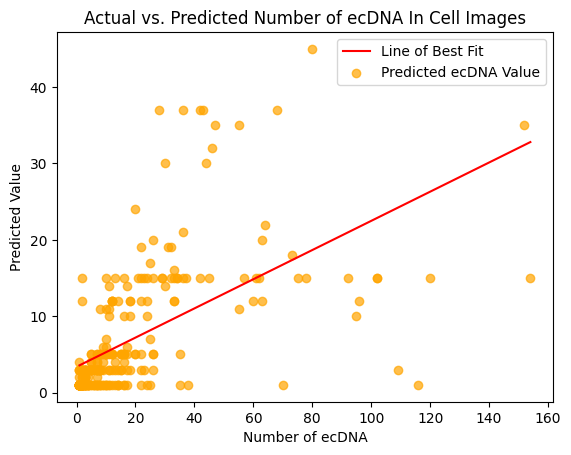

In [ ]:
# Graph scatter plot
actual, predicted = filter_data(results_df['ec'], results_df['pred'])

coefficients = np.polyfit(actual, predicted, 1)
slope = coefficients[0]
intercept = coefficients[1]
line_x = np.array([min(actual), max(actual)])
line_y = slope * line_x + intercept

plt.plot(line_x, line_y, color='red', label="Line of Best Fit")  # Add the line to the plot
plt.scatter(actual, predicted, color='orange', alpha=0.7, label='Predicted ecDNA Value')


plt.xlabel('Number of ecDNA')
plt.ylabel('Predicted Value')
plt.title('Actual vs. Predicted Number of ecDNA In Cell Images')

plt.legend()
plt.show()

In [17]:
methods = ['Zero Shot', 'Three Shot', 'Multi-Layer', 'Temp=0.2']
mae = [calc_metrics(d['ec'], d['pred'])[0] for d in df_list]
rmse = [calc_metrics(d['ec'], d['pred'])[1] for d in df_list]

In [24]:
rmse

[21.47796615843852, 17.099542865152365, 26.625120822702936, 30.67196163875455]

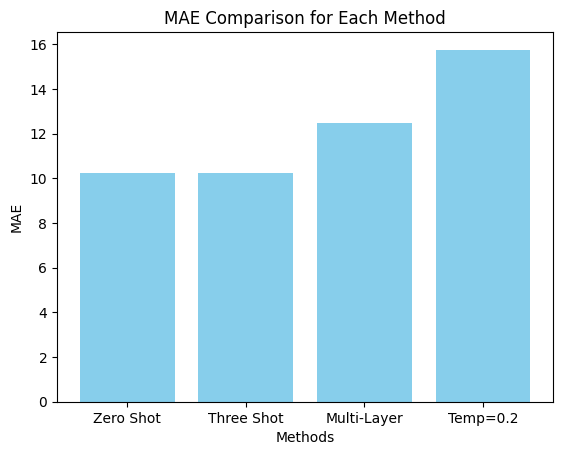

In [18]:
# Plot MAE Bar Graph
plt.bar(methods, mae, color='skyblue')

plt.xlabel('Methods')
plt.ylabel('MAE')
plt.title('MAE Comparison for Each Method')

plt.show()

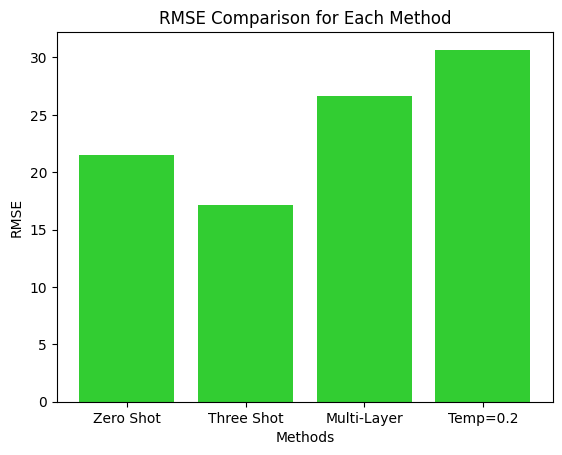

In [22]:
# Plot RMSE Bar Graph
plt.bar(methods, rmse, color='limegreen')

plt.xlabel('Methods')
plt.ylabel('RMSE')
plt.title('RMSE Comparison for Each Method')

plt.show()

In [28]:
calc_metrics(results_df['ec'].mean(), results_df['pred'].mean())

AttributeError: 'numpy.ndarray' object has no attribute 'abs'

In [29]:
(results_df['ec'].mean() - results_df['pred'].mean())

7.1625

In [30]:
np.sqrt((results_df['ec'].mean() - results_df['pred'].mean()) ** 2)

7.1625